# Data Insights Targets
Making basic overview about the dataset with these target
1. Columns type : [ Discreet dataset | Continuous dataset | Categorical or classificaiton dataset ]
2. Making basic stats about missing units and data set

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

data_path = '/home/madhavrimal/workspace/Projects/vizion/data/crop_dataset.csv'
demo_data = '/home/madhavrimal/workspace/Projects/vizion/testing_dataset.csv'
illness_dataset = 'Final_Augmented_dataset_Diseases_and_Symptoms-selected-columns.csv'
space_dataset = 'data/Global_Space_Exploration_Dataset.csv'

df = pd.read_csv(data_path)

# Classification of dataset
''' Using Pandas Api for data classification which could fail with 
inconsistent data types passed into the main stream
Must required Preprocessing and cleanups
1. Removing inconsistent or fixing inconsistent data types
2. Units patches inconsistent units across the measurements could affect more
3. null safety is also required before passing into classification unit
'''
THRESH = 0.4
continuous = []
discrete = []
categorical = []
other = []

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        if df[col].dtype == 'float64':
            continuous.append(col)
        else:
            discrete.append(col)
    # Native check for the categorical dataset 
    elif isinstance(df[col].dtype , pd.CategoricalDtype):
        categorical.append(col)
        
    elif pd.api.types.is_string_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
        unique_ratio = df[col].nunique() / len(df)  # THRESHOLD FOR CATEGORICAL

        if unique_ratio <= THRESH:
            categorical.append(col)
            df[col] = df[col].astype('category') # converting dtype into category
        
    elif pd.api.types.is_string_dtype(df[col]):
        other.append(col)

# Making Very Basic Broad overview about dataset
print(f"""Summary about dataset
continuous : {continuous} | discrete : {discrete} |  categorical : {categorical} | others : {other}""")

Summary about dataset
continuous : ['Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'] | discrete : ['Crop_Year', 'Production'] |  categorical : ['Crop', 'Season', 'State'] | others : []


# Dataset Analysis Branch
1. Categorical
2. Numerical

**Reference Topics**

* Chi-square test of independence
* Cramer's V
* Cross-tabular heatmap with stacked bar charts
* Pearson Correlation Coefficient
* K-Means Clustering | Making geometric clustering of dataset
* ANOVA test F-statistic
* P-flag for weak relationships

Plot Mess Problem
Making plot with too many dataset categorical makes more problem
    FIxing with limiting the categorical dataset which could be fited into visual
    Making difference between identity based columns, like id and other unique identification units
    Narrow visualisation with one perticular category for the final visualization

Visualization Units
~ BOX plots voilin plot
~ Bar Plot
~ Ridgeline/ Overlaping kde waves

Execution Plan
+ Making good numerical analysis before ploting is must required
    Uniq unit diff | uniq identification stream would be used for making narrow specific plots
+ Relation study along with given best pairs with plot plan required for making plots

---------

# Numerical Dataset relation visualization unit

ISSUE WITH PANDAS INBUILT CLASSIFICATION :
    Making strict rules for passing for the data type

    New Addon : Making custom random sample based approach for data type detection
        handle edge cases with  given issuues and logic alternatives
        Making simple logics for the data detection with random sample | After data cleanup and preprocessing

Numerical dataset classification unit Issues
    Cross conversion possible units
        with entry 4.00 like its discreete not continuous dataset, 
        with some edge cases of discreete and continouous dataset available to solve

    ## Numerical Data Analysis Trend and relation initial Visualization
        1. Sorting with numerical dataset 
        2. Observe dataset trends with the given numerical numbers
        3. Numerical column which while sorted gives trend in numerical dataset is taken for the one access visualization

Discrete Dataset Overiveiw
    **ISSUE** : Taking year into the discrete category
        + Logic for time stamp detection or asking user about
            Checking given dataset columns with equal difference
                If the numerical units consists of equal difference -> Time flag

In [109]:
#continuous
import random
import matplotlib.pyplot as plt

TARGET_VALUE = 'Yield'

colors = ['red', 'blue', 'green']

cont = continuous
print(cont)

yeild_data = df['Yield']


plt.plot(df['Annual_Rainfall'], yeild_data)
plt.xlabel('Anural_Rainfall')
plt.ylabel('Yeild Data')

print(df['Annual_Rainfall'])

plt.show()

# Making scatter with these dataset

['Budget (in Billion $)']


KeyError: 'Yield'

## Pearson Coeficient 

Statistical Measure for Quantifying relation strength
**Key Constraints**
1. Linearity
2. Continuous Data
3. Outlier sensitive calculation
4. Normality of dataset
------
        Ratio of covariance of both variable with standard measure about both variable spread relative to center

$$
r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}}
$$


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# continuous dataset relations
corr = df[continuous].corr(method='pearson')

# Ploting respective dataset 
plt.figure(figsize=(6, 5))

# 5. Plot the filtered heatmap
sns.heatmap(
    corr, 
    annot=True,       # Displays the correlation numbers inside the squares
    cmap='Greens',  # Red for positive, blue for negative relationships
    fmt=".2f",        # Rounds the display numbers to 2 decimal places
    vmin=-1,          # Keeps the scale bound exactly to Pearson limits
    vmax=1
)

# 6. Add labels and optimize layout
plt.title('Correlation Matrix for Selected Columns', fontsize=12, pad=12)
plt.tight_layout()
plt.show()


# Numerical Relations Methods
1. Predictive Power Score
2. Maximal Information Coefficient
3. Mutual Information index
4. Distance Correlation
5. Hoeffding's D

## Predictive Power Score
Make regression tree fit for the dataset, and compute the final resedual which tells about the actual dependency about the dataset , How much the actual values are depended, Non-Linear Relations and hidden trends could be studied with the model and its gauge.

### Decision Tree Regression

    Making chain of dependency of conditions for making predictions with given input form by making simple conditional nodes
    Chain of multiple conditions w.r.t Dataset for  building the final tree
    Importance : Can handle multiple dependency variables for building the final tree

**Method for Building**
-- Single Valued

* Residual Graphing with split average
    Iterate with split into dataset, take their average as threshhold and compute residual form rest of the dataset , plot the resedual and iterate for for theh whole dataset split groups

* Split for final Nodes with depth

    Spliting the dataset for  nodes based on residual graph split of local minimum and local features, Making final root node with lowest residual and bbuilding for other based on depth of tree decieded in first

  We get final Model with respect to the dataset


-- Multi valued
    Chain the relation with comparing residual with all variable to the dataset and compute multi variable dependency chain 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, mean_absolute_error

def calculate_pps(df, feature_col, target_col):
    data = df[[feature_col, target_col]].dropna()
    if len(data) < 10:
        print(f"Terminating Computation less dataset")
        return 0.0
    # Classification Route for classification unit

    X = pd.get_dummies(data[[feature_col]], drop_first=True)
    y  = data[target_col]

    median_val = y.median()
    # Filling Empty values into the main frame
    y_naive = np.full(shape=y.shape, fill_value=median_val)
    naive_score = mean_absolute_error(y, y_naive)

    # Perfect Score
    perfect_score = 0.0

    model = DecisionTreeRegressor(max_depth=4, random_state=42)
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
    model_score = -np.mean(scores)

    if (perfect_score - naive_score) == 0: return 0.0
    pps = (model_score - naive_score) / (perfect_score - naive_score)
    
    return max(0.0, min(1.0, pps))

def pps_matrix(column_list):
    columns = column_list
    matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)
    for col_x in columns:
        for col_y in columns:
            if col_x == col_y:
                matrix.loc[col_y, col_x] = 1.0
            else:
                matrix.loc[col_y, col_x] = calculate_pps(df, col_x, col_y)
    return matrix

pps_matrix(continuous)

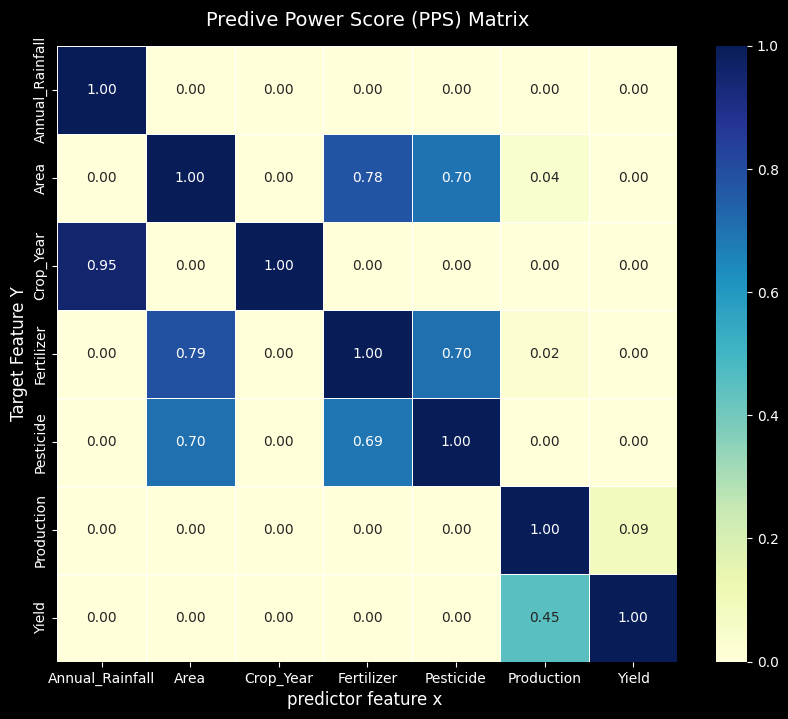

[{'x': 'Fertilizer', 'y': 'Fertilizer', 'ppscore': 1, 'case': 'predict_itself', 'is_valid_score': True, 'metric': None, 'baseline_score': 0, 'model_score': 1, 'model': None}, {'x': 'Fertilizer', 'y': 'Yield', 'ppscore': 0, 'case': 'regression', 'is_valid_score': True, 'metric': 'mean absolute error', 'baseline_score': 77.1771619823422, 'model_score': np.float64(149.84642238069188), 'model': DecisionTreeRegressor()}, {'x': 'Fertilizer', 'y': 'Crop_Year', 'ppscore': 0, 'case': 'regression', 'is_valid_score': True, 'metric': 'mean absolute error', 'baseline_score': 5.6186, 'model_score': np.float64(7.1396), 'model': DecisionTreeRegressor()}, {'x': 'Fertilizer', 'y': 'Production', 'ppscore': 0, 'case': 'regression', 'is_valid_score': True, 'metric': 'mean absolute error', 'baseline_score': 14338252.315, 'model_score': np.float64(25449441.609646663), 'model': DecisionTreeRegressor()}, {'x': 'Fertilizer', 'y': 'Pesticide', 'ppscore': np.float64(0.6948606352403401), 'case': 'regression', 'is_

In [113]:
import ppscore as pps
import pandas as pd
import seaborn as sns

TARGET_VALUE = 'Yield'

# Data lising units
numerical = []
numerical.extend(continuous)
numerical.extend(discrete)

numerical = list(set(numerical))


scores = []
for _ in numerical:  # categorical dataset
    for t in numerical: # numerical and discrete dataset listing
        score = pps.score(df, _, t)
        scores.append(score)

# Visualization of given Scores
df_scores = pd.DataFrame(scores)
# Pivot based modeling for the given
matrix_df = df_scores.pivot(index='y', columns='x', values='ppscore')
matrix_df.fillna(0)

plt.figure(figsize=(10,8))

sns.heatmap(
    matrix_df,
    vmin=0,
    vmax=1,# ranging PPS with given range
    cmap='YlGnBu', # Color gradient
    annot=True, # write exact scores
    fmt='.2f', # Number Format
    linewidth=0.5,
)

plt.title('Predive Power Score (PPS) Matrix', fontsize=14, pad=15)

plt.xlabel('predictor feature x ', fontsize=12)
plt.ylabel('Target Feature Y', fontsize=12)
plt.show()
print(scores)

## Predictive Power Scrore and Statistical Refinement
More statistical foundational ranking units required predictive power score is not able to give clarity with the dataset,

Needs refined approach for making the data analysis for the final ranking of plot, Pearson correlation Matrix is working fine
More such simple statistical measures required

In [ ]:
import pandas as pd

df_consumption = pd.read_csv('worldwide_crop_consumption.csv')

df_consumption.head()

Index(['Value'], dtype='object')


/tmp/ipykernel_28335/2274367854.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aggregation, x='LOCATION', y='Value', palette='magma')


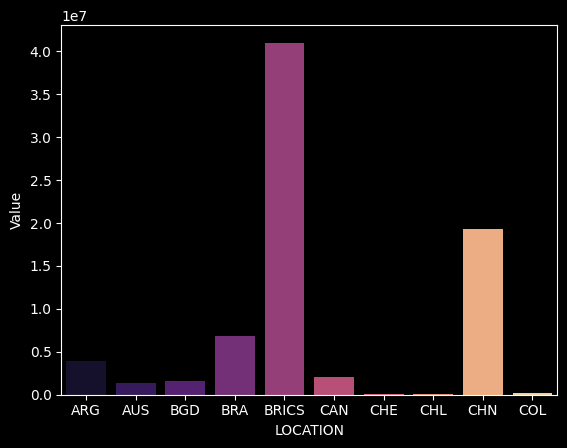

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
# Making Visualization attempts with combination of categorical with numerical Entities
limit = 10
plt.style.use('dark_background')
aggregation = pd.DataFrame(df_consumption.groupby('LOCATION')['Value'].sum()[:limit])
print(aggregation.columns)

sns.barplot(data=aggregation, x='LOCATION', y='Value', palette='magma')

plt.show()

# Statistical Inference
Inference with statistical inference about dataset
    Independence rules, Bayes Rule based modeling variables

Random Variable distribution
1. Discrete 
2. Continuous

Probability combination making | Joint Probability

Transformation of Variable | Modeling random variables with making equational modeling of variables.

Distribution Fit 
1. Discrete Distribution | Binomial distribution
2. Continuous Distribution  | Normal distribution

### AIM : Making automated engine for making random variable Processor and distribution modeling unit for making prediction models and understanding data set with statistical inference report

Automated Engine Features
1. Random Variable based modeling of given variables modeling into respective distribution\
    > Requires Generic Modeling unit which can be used for training for different models distribution fiting
    > With gradient decent | Linear Algebra based approach for the given Fit
2. Report with dependency variable with their distribution Modeling unit
3. Inferencing information with given distribution along -> Visualization Keen
   > Core Inference Reporting